# Correspondence tables

In [1]:
# Import relevant libraries
import pandas as pd 
from thefuzz import fuzz
from thefuzz import process
import numpy as np
import json
import unidecode
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 Appending correspondence table (Builtwith)
Read the following datasets:
+ perfect match
+ unimodal
+ multimodal
+ multimodal_only_one_url_retrieved 


In [2]:
# Read all datasets required to create the correspondence table
perfect_match_builtwith = pd.read_stata("../../Data/India/processed_data/perfect_match_builtwith_IND.dta")
unimodal_builtwith = pd.read_stata("../../Data/India/processed_data/unimodal_builtwith_IND.dta")
multimodal = pd.read_csv("../../Data/India/processed_data/multimodal_IND.csv")
multi_only_one_match_web = pd.read_csv("../../Data/India/processed_data/one_url_retrieved_cases_IND.csv")

# Check the size of the datasets
print(perfect_match_builtwith.shape)
print(unimodal_builtwith.shape)
print(multimodal.shape)
print(multi_only_one_match_web.shape)

(125488, 7)
(3681, 7)
(1269, 7)
(7718, 8)


In [3]:
# Append all datasets
correspondence_table_ = pd.concat([perfect_match_builtwith, unimodal_builtwith, multimodal, multi_only_one_match_web])

# Drop Unnamed column
correspondence_table_ = correspondence_table_.drop(columns=['Unnamed: 0'])
print(correspondence_table_.shape)

# Display table
correspondence_table_.head(20)


(138156, 7)


,old_id,new_id,old_id_website,panjiva_raw_firm_name,builtwith_website,final_website,type
0,IND1,IND15238,IND1,Tranter India Private Ltd.,tranter.com,tranter.com,perfect_match
1,IND100000,IND317254,IND100000,Ace Sports United,acesportsunited.com,acesportsunited.com,perfect_match
2,IND100005,IND182525,IND100005,Tenet Medcorp Private Ltd.,tenetdiagnostics.in,tenetdiagnostics.in,perfect_match
3,IND100007,IND387218,IND100007,Twins Digital Services India Private Ltd.,twinsdigital.com,twinsdigital.com,perfect_match
4,IND10001,IND341540,IND10001,Idea Plus Imp.,ideasplus.co.in,ideasplus.co.in,perfect_match
5,IND100012,IND100392,IND100012,Boss Air Compressor,bosscompressor.com,bosscompressor.com,perfect_match
6,IND100016,IND224961,IND100016,Ernakulam Archdiocesan Publication Trust,lisiehospital.org,lisiehospital.org,perfect_match
7,IND100019,IND17655,IND100019,Superlite Aac Block Industry.,kamakhyasuperlite.com,kamakhyasuperlite.com,perfect_match
8,IND100021,IND298512,IND100021,Yantralive Parts Technology Private Ltd.,yantralive.com,yantralive.com,perfect_match
9,IND100023,IND157327,IND100023,Vama Lifecare Private Ltd.,vamalifecare.com,vamalifecare.com,perfect_match


In [4]:
#correspondence_table_ = correspondence_table.head(2000)
#correspondence_table_ = correspondence_table[correspondence_table["type"] == "non_clear_mode_but_website_group"]

##  1.2. Preprocessing

For the preprocessing step, we use the following procedure:

1. **Normalization and Cleaning**:
   - **Lowercase Conversion and Accent Removal**: All text data, including company names and website URLs, are converted to lowercase to standardize the format and ensure uniformity in processing. Additionally, accents are removed using `unidecode`. These accents are often found in company names but rarely in website URLs.
   - **Removal of Common Business Suffixes**: Business-related suffixes such as "SA DE CV", "S.A. DE C.V.", and others are removed from company names. This step is crucial for aligning company names more closely with their website, which typically does not include such formal identifiers.

2. **Character Filtration**:
   - **Non-Alphanumeric Character Removal**: All non-alphanumeric characters, including spaces, commas, periods, and hyphens, are stripped from both names and URLs. This reduces noise and prevents mismatches that can occur due to irrelevant characters or spacing issues in the data.

3. **Extraction and Utilization of Initials**:

    - **Initials Extraction**: This step involves selecting the first letter of each significant word in the company's name to form a set of initials. Words considered insignificant, such as common conjunctions, prepositions, or those shorter than three letters, are excluded ('la', 'el', 'de', 'los', etc.). For instance:
      - For `MERCK SHARP & DOHME COMERCIALIZADORAS DE RL DE CV`, the significant words are `MERCK`, `SHARP`, `DOHME`, and `COMERCIALIZADORAS`.
      - The initials extracted from these words are `MSDC`, which represents a concise representation of the company's name.
    - **Usage in Comparisons**: These initials, "MSDC", can be directly compared to website names. In this case, the website "msd.com" shares the initials "MSD", which is a partial match to the extracted initials from the company name. This commonality in initials suggests a strong linkage between the company name and the website, enhancing the accuracy of matching in scenarios where such abbreviations or acronyms are used in domain names. 

    This method of using initials helps in effectively matching company names with their corresponding websites, especially when websites utilize acronyms or initials as their domain names.

4. **Website URL Simplification**:
   - **Domain Simplification**: Common web prefixes (like "www.") and suffixes (such as ".com", ".org", ".net") are removed from URLs to focus on the core part of the domain, which is essential for direct comparisons with company names.
   - **Conditional Geographic Indicator Removal**: The presence of geographic indicators like ".mx" or ".mex" is conditionally managed based on the content of the company name. If terms related to "Mexico" (such as "mexico" or "mex") are found in the cleaned company name, these indicators are preserved in the URL to enhance specificity in matching. Conversely, if such indicators are absent, they are removed to prevent potential false associations and simplify the domain further.

5. **Application of Conditional Logic**:
   - **Geographic Relevance**: The logic implemented ensures that geographic relevance is maintained by preserving country-specific domain extensions like ".in" or ".ind" when the company name suggests a Indian association. This approach helps in accurately identifying and matching companies with their respective web domains, especially in localized contexts.

By implementing these preprocessing steps, the goal is to standardize and optimize the input data for more effective matching, especially when using fuzzy logic or other matching algorithms. This preparation is key to minimizing discrepancies and enhancing the accuracy of identifying matches between company names and their corresponding websites.

In [5]:
# Updated list of Indian suffixes and insignificant words
indian_suffixes = ["pvt.", "pvt", "ltd.", "ltd", "private", "limited", "llp", "(p)", " p. ", "l.p.", 
                   "plc", "corp", "corporation", "inc.", "llc", "llp", "pvt. ltd.",
                   "pvt. ltd", "private ltd", "private ltd.", "co.", " co ", "&", " and ", " of ", " an ", 
                   " exp. ", " imp. ",  "liability partnership" ," li ", ",", " opc ", "exp.", "imp.", "(", ")", "+"]

indian_insignificant_words = ["and", "of", "an", "at", "by", "from", "for", "with", "to", "in", "&", ",", "(", ")"]

# Helper function to clean and extract initials
def extract_initials(name):
    words = [word for word in name.split() if word not in indian_insignificant_words]
    return ''.join([word[0] for word in words])

# Main preprocessing function
def preprocess(name, website):
    # Normalize: lowercase and remove accents
    name = unidecode.unidecode(name.lower())
    website = unidecode.unidecode(website.lower())
    
    # Remove common suffixes and other non-alphanumeric characters from name
    for suffix in indian_suffixes:
        if suffix in [" and ", " of ", " an "]:
            name = name.replace(suffix, ' ') # Leave a white space
        else:
            name = name.replace(suffix, '') # Do not leave space
 
    
    # Initials are extracted from the cleaned name
    initials = extract_initials(name)
    
    # Remove all non-alphanumeric characters from name
    name = ''.join(e for e in name if e.isalnum())
        
    if any(x in name for x in ['in', 'ind', 'india']):
        website = website.replace('www.', '').replace('.com', '').replace('.org', '').replace('.net', '').replace('.gob', '').replace('.co', '')
    else:
        website = website.replace('.in', '').replace('www.', '').replace('.com', '').replace('.org', '').replace('.net', '').replace('.gov', '').replace('.co', '')

    # Remove all remaining non-alphanumeric characters from website
    website = ''.join(e for e in website if e.isalnum())

    return name, website, initials

# 1.3. Scoring algorithm for string similarity between final Builtwith websites and Panjiva names


#### Levenshtein Distance and FuzzyWuzzy

The `fuzzywuzzy` Python package, which is utilized in this code, leverages the Levenshtein distance to calculate differences between sequences (i.e., text strings). This method measures the minimum number of single-character edits (insertions, deletions, or substitutions) required to change one word (string) into another. The package provides various ways to compare strings, which are essential in determining the similarity and thereby assisting in matching company names to their respective websites.


#### Normalization of Similarity Scores

Similarity scores are normalized percentages derived from the Levenshtein distance. They are calculated as follows:

$$\text{Similarity Score} = 100 \times \left(1 - \frac{\text{Levenshtein distance}}{\text{maximum string length}} \right)$$

A similarity score of 100 indicates an exact match between strings, whereas a score closer to 0 indicates greater dissimilarity.

#### Key Scores Used
1. **Ratio**: This score calculates the standard Levenshtein distance similarity between two strings on a scale from 0 to 100. It’s useful for direct, full-string comparisons.
2. **Partial Ratio**: Compares partial segments of the string, focusing on the best matching substring. This is particularly useful when matching initials or abbreviations to longer strings.
3. **Token Sort Ratio**: Compares two strings by sorting their tokens alphabetically and then joining them back into a single string, thus removing the impact of word order.
4. **Token Set Ratio**: Compares strings based on shared words, regardless of order or additional words. It splits strings into tokens, finds common words, combines them with the best matching unique tokens, then calculates similarity. This method is ideal for matching variations of names that have the same core words but may include extras or be in a different order.

#### Process for Identifying the Best Website

1. **Preprocessing**:
   - Convert each company name and website URL to lowercase.
   - Remove accents from characters.
   - Strip common business suffixes.
   - Remove non-alphanumeric characters.

2. **Scoring**:
   - Compare the preprocessed website against the preprocessed company name and the initials of the preprocessed company name.
   - Compute four distinct similarity scores (ratio, partial ratio, token sort ratio, token set ratio) between the cleaned company name and the cleaned website.
   - Calculate the **Average score** by averaging the above four scores.
   - Calculate the **Initials score** by comparing the cleaned website with the initials of the preprocessed company name using only the partial ratio score.
   - Decide which score to use (Average score or Initials score) based on the following conditions:
     * The Initials score must be greater than 85.
     * The Initials score must exceed the Average score.
     * The string length of the initials must be more than 1 character.
     * The cleaned website's length must be less than 6 characters.
     
    If any condition is not met, the Average score is used; otherwise, the Initials score is considered.

In [6]:
# Define thresholds 
th_init = 85        # Threshold to define when to use initials over the avg_score

In [7]:
# Empty list to store results
data_list = []

# Iterate over unique new_ids
for new_id in correspondence_table_["new_id"].unique():
    # Filter dataset for the current new_id
    df_filtered = correspondence_table_[correspondence_table_["new_id"] == new_id]

    # Iterate over each row of the filtered DataFrame
    for index, row in df_filtered.iterrows():
        # Get relevant variables from the row
        old_id = row["old_id"]
        panjiva_raw_name = row["panjiva_raw_firm_name"]
        old_id_website = row["old_id_website"]
        builtwith_website = row["builtwith_website"]
        final_website = row["final_website"]
        record_type = row["type"]
        
        # Initialize variable to keep track of maximum score
        max_score = 0
        
        # Preprocess raw name and website, and extract initials
        clean_name, clean_website, initials = preprocess(panjiva_raw_name, final_website)

        # If "india" is in the website but not in the name, append "india" to the name
        if "india" in clean_website and "india" not in clean_name:
            clean_name = clean_name + "india"
        
        # Fuzzy matching scores for different methods
        score_ratio = fuzz.ratio(clean_name, clean_website)
        score_partial_ratio = fuzz.partial_ratio(clean_name, clean_website)
        score_token_sort_ratio = fuzz.token_sort_ratio(clean_name, clean_website)
        score_token_set_ratio = fuzz.token_set_ratio(clean_name, clean_website)
        
        # Calculate the weighted average score
        avg_score = (0.30 * score_ratio + 0.40 * score_partial_ratio + 0.15 * score_token_sort_ratio + 0.15 * score_token_set_ratio)
        
        # Calculate initials score
        initials_score = fuzz.partial_ratio(initials, clean_website)

        # Determine the max score (either initials score or avg_score)
        if initials_score >= th_init and initials_score > avg_score:
            max_score = initials_score
        else:
            max_score = max(max_score, avg_score)
        
        # Store the results in data_list, preserving original variables and scores
        data_list.append({
            "old_id": old_id,
            "new_id": new_id,
            "old_id_website": old_id_website,
            "panjiva_raw_firm_name": panjiva_raw_name,
            "builtwith_website": builtwith_website,
            "final_website": final_website,
            "type": record_type,
            "cleaned_name": clean_name,
            "cleaned_website": clean_website,
            "initials": initials,
            "score_ratio": score_ratio,
            "score_partial_ratio": score_partial_ratio,
            "score_token_sort_ratio": score_token_sort_ratio,
            "score_token_set_ratio": score_token_set_ratio,
            "initials_score": initials_score,
            "max_similarity_score": max_score
        })

# Create a DataFrame from the collected data
correspondence_table = pd.DataFrame(data_list)

# Print the resulting DataFrame
correspondence_table


,old_id,new_id,old_id_website,panjiva_raw_firm_name,builtwith_website,final_website,type,cleaned_name,cleaned_website,initials,score_ratio,score_partial_ratio,score_token_sort_ratio,score_token_set_ratio,initials_score,max_similarity_score
0,IND1,IND15238,IND1,Tranter India Private Ltd.,tranter.com,tranter.com,perfect_match,tranterindia,tranter,ti,74,100,74,74,67,84.4
1,IND100000,IND317254,IND100000,Ace Sports United,acesportsunited.com,acesportsunited.com,perfect_match,acesportsunited,acesportsunited,asu,100,100,100,100,67,100.0
2,IND100005,IND182525,IND100005,Tenet Medcorp Private Ltd.,tenetdiagnostics.in,tenetdiagnostics.in,perfect_match,tenetmed,tenetdiagnostics,tm,50,86,50,50,67,64.4
3,IND100007,IND387218,IND100007,Twins Digital Services India Private Ltd.,twinsdigital.com,twinsdigital.com,perfect_match,twinsdigitalservicesindia,twinsdigital,tdsi,65,100,65,65,57,79.0
4,IND10001,IND341540,IND10001,Idea Plus Imp.,ideasplus.co.in,ideasplus.co.in,perfect_match,ideaplus,ideasplus,ip,94,88,94,94,67,91.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138151,IND53217,IND9983,IND53217,K H And Co.,enterprisescosmos.com,enterprisescosmos.com,multimodal_only_one_url_retrieved,kh,enterprisescosmos,kh,0,0,0,0,0,0.0
138152,IND395079,IND9983,IND53217,Kh And Co.,enterprisescosmos.com,enterprisescosmos.com,multimodal_only_one_url_retrieved,kh,enterprisescosmos,k,0,0,0,0,0,0.0
138153,IND76353,IND9983,IND53217,K.H. And Co.,enterprisescosmos.com,enterprisescosmos.com,multimodal_only_one_url_retrieved,kh,enterprisescosmos,k,0,0,0,0,0,0.0
138154,IND73601,IND99921,IND73601,A P Cork Industries,ajretails.com,ajretails.com,multimodal_only_one_url_retrieved,apcorkindustries,ajretails,apci,40,46,40,40,50,42.4


In [28]:
# pd.set_option('display.max_rows', None)
# display(correspondence_table[correspondence_table['type'] == 'perfect_match'].sort_values(by='max_similarity_score', ascending=True))
# display(correspondence_table[correspondence_table['type'] == 'multimodal_best_website'].sort_values(by='max_similarity_score', ascending=True))
# display(correspondence_table[correspondence_table['type'] == 'non_clear_mode_but_website_group'].sort_values(by='max_similarity_score', ascending=True))
# display(correspondence_table[correspondence_table['type'] == 'non_clear_mode_but_correct_website'].sort_values(by='max_similarity_score', ascending=True))
# display(correspondence_table[correspondence_table['type'] == 'non_clear_mode_and_non_correct_website'].sort_values(by='max_similarity_score', ascending=True))
# display(correspondence_table[correspondence_table['type'] == 'unimodal'].sort_values(by='max_similarity_score', ascending=True))
# display(correspondence_table[correspondence_table['type'] == 'multimodal_only_one_url_retrieved'].sort_values(by='max_similarity_score', ascending=True))
# pd.reset_option('display.max_rows')
display(correspondence_table[
    ['old_id', 'new_id', 'old_id_website', 'panjiva_raw_firm_name', 'builtwith_website', 'final_website', 'type', 'max_similarity_score']
].loc[correspondence_table['type'] == 'non_clear_mode_and_non_correct_website'].sort_values(by='max_similarity_score', ascending=True))


,old_id,new_id,old_id_website,panjiva_raw_firm_name,builtwith_website,final_website,type,max_similarity_score
129677,IND163450,IND256319,NaN,Ddg Ppo Mgo's Branch,icar.gov.in,icar.gov.in,non_clear_mode_and_non_correct_website,19.2
129522,IND224022,IND213747,NaN,V.S.Rekha,delhihighcourt.nic.in,delhihighcourt.nic.in,non_clear_mode_and_non_correct_website,24.6
129523,IND230440,IND213747,NaN,V S Rekha Asian,justahotels.com,justahotels.com,non_clear_mode_and_non_correct_website,27.6
129812,IND64954,IND295935,NaN,Nice Imp. & Exp.,giri.in,giri.in,non_clear_mode_and_non_correct_website,31.0
130258,IND421578,IND55588,NaN,A.R.Exporters (India),naushie.com,naushie.com,non_clear_mode_and_non_correct_website,31.6
129676,IND174115,IND256319,NaN,Ddg Ppc Mgos Branch (Indian Army),bro.gov.in,bro.gov.in,non_clear_mode_and_non_correct_website,34.4
129764,IND144278,IND279446,NaN,Command Hospital Luckhnow,nhp.gov.in,nhp.gov.in,non_clear_mode_and_non_correct_website,40.6
129472,IND328806,IND195687,NaN,Gagan Deep Chemicals Industries,iocl.com,iocl.com,non_clear_mode_and_non_correct_website,41.4
129473,IND416401,IND195687,NaN,Gagandeep Chemical Industries,shreeharitraders.in,shreeharitraders.in,non_clear_mode_and_non_correct_website,42.4
129813,IND200497,IND295935,NaN,Nice Exporters,mylalexports.com,mylalexports.com,non_clear_mode_and_non_correct_website,60.4


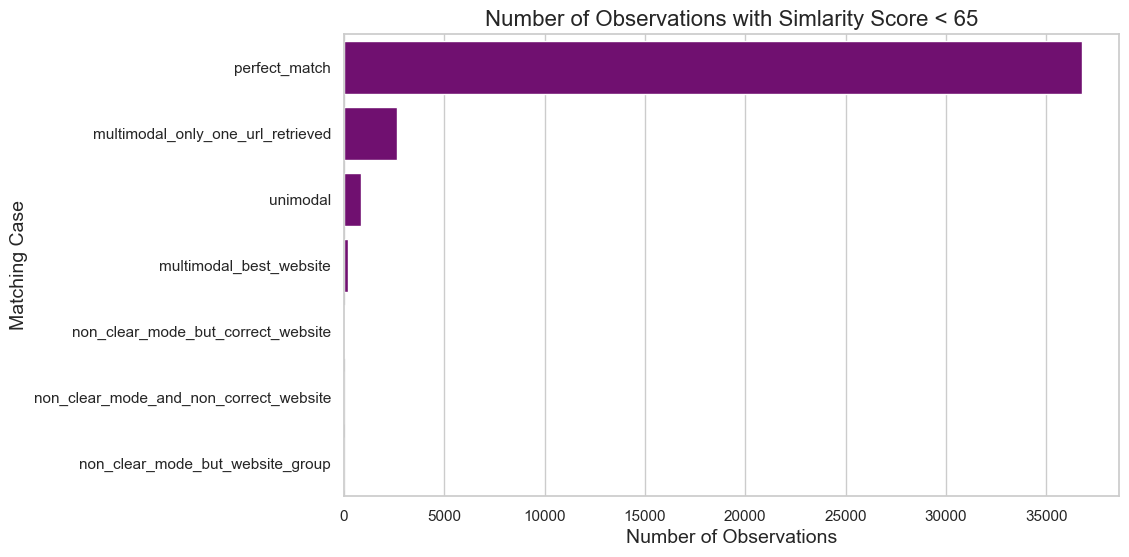

In [23]:
# Filter the dataset for scores less than 65
filtered_data = correspondence_table[correspondence_table['max_similarity_score'] < 65]

# Group by 'type' and count the number of observations
obs_by_type = filtered_data.groupby('type').size().reset_index(name='count')

# Sort the data by 'count' in ascending order
obs_by_type = obs_by_type.sort_values(by='count', ascending=False)

# Set plot size and style
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Create a horizontal bar plot for the number of observations with score < 65 by type
sns.barplot(y='type', x='count', data=obs_by_type, color='purple')

# Add labels and title
plt.title('Number of Observations with Simlarity Score < 65', fontsize=16)
plt.xlabel('Number of Observations', fontsize=14)
plt.ylabel('Matching Case', fontsize=14)

# Show the plot
plt.show()


c:\WBG\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


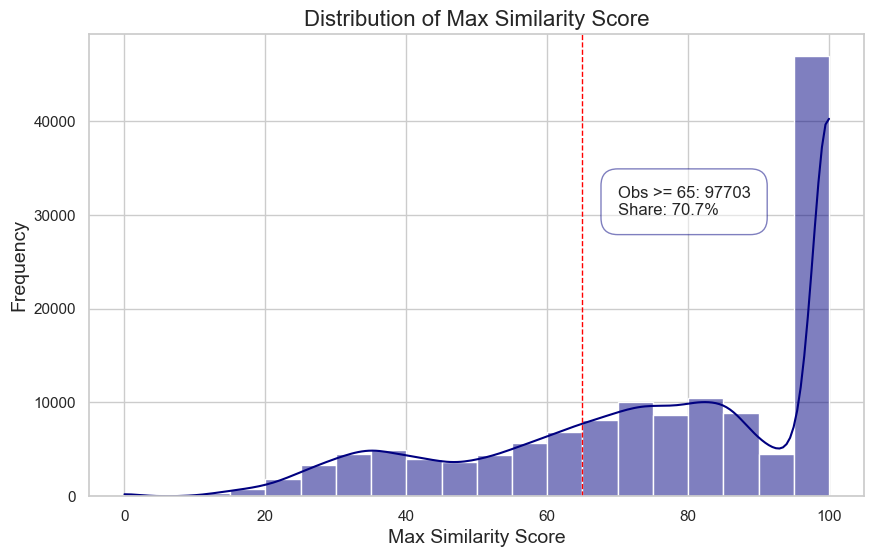

In [11]:
# Set the plot size and style
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Create a distribution plot
sns.histplot(correspondence_table['max_similarity_score'], bins=20, kde=True, color='navy')

# Add a vertical dashed line at score 65
plt.axvline(x=65, color='red', linestyle='--', linewidth=1)

# Calculate the number of observations >= 65 and the percentage
obs_greater_equal_65 = correspondence_table[correspondence_table['max_similarity_score'] >= 65].shape[0]
total_obs = correspondence_table.shape[0]
share = (obs_greater_equal_65 / total_obs) * 100 if total_obs > 0 else 0

# Add a text box with the statistics
plt.text(70, 30000, f'Obs >= 65: {obs_greater_equal_65}\nShare: {share:.1f}%', 
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='navy', boxstyle='round,pad=1'), fontsize=12)

# Add labels and title
plt.title('Distribution of Max Similarity Score', fontsize=16)
plt.xlabel('Max Similarity Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Show the plot
plt.show()


In [12]:
# Save final correspondence table
correspondence_table.to_csv('../../Data/India/processed_data/correspondence_table_IND.csv', index=False)

## 1.2 correspondence table (Aberdeen)
Read the following datasets:
+ perfect match
+ unimodal
+ multimodal best website
+ multimodal non clear mode but website group
+ multimodal non clear mode but correct website
+ multimodal non clear mode and non correct website
+ multimodal_only_one_url_retrieved 
